In [4]:
import numpy as np
import io

import matplotlib.pyplot as plt

import sys
import os

# Assuming /AutomationModule is in the root directory of your project
sys.path.append(os.path.abspath(r'../../../../tidy3d'))

from AutomationModule import * 

import AutomationModule as AM

In [5]:
file_path=r"./Structures/endtoend/20260624_lsu_fromrandom_N4000_ends.txt"

In [6]:
def create_permittivity_grid_penlike(
    rod_endpoints,
    grid_size=128,
    minor_radius=0.1,        # circular radius in the pre-warp space (becomes ellipse after z-warp)
    aspect_ratio=None,        # global z scale factor s; ellipses have major/minor = s (projected)
    aspect_ratio_hole=None,        # global z scale factor s; ellipses have major/minor = s (projected)
    permittivity=3.42**2, #Si
    permittivity_bg=1.0,
    hole_minor_radius=0.0,   # inner circular radius in pre-warp space (same eccentricity after warp)
    box_size=None,
    *,
    progress_every=20,
    dinamic_radius=False,
    sigma_inner=None,
    sigma_outer=None,
    mean_inner=None,
    mean_outer=None,
    create_hole=False,
    use_radius_array=False,
    b_list=None,
    b_h_list=None,
    verbose=False

):
    """
    Build hollow 'pen-like' rods by:
      (1) creating RIGHT CIRCULAR cylinders in an unwarped space (x, y, z'),
      (2) applying a GLOBAL z warp: z = s * z'.

    IMPORTANT:
      - 'rod_endpoints' are given in FINAL (post-warp) world coords.
      - We unwarp them internally: z' = z / s.
      - Because the warp is GLOBAL, both shell and hole share the SAME ellipticity.
        You can set different radii (thickness), but not different ellipse ARs.

    Geometry:
      - Axis unit vector and clamping 0<=t<=L are computed in UNWARPED space.
      - Membership test is purely circular in UNWARPED cross-sections.
      - All ellipses are aligned with the projection of +z into each rod cross-plane.
        For rods parallel to z, the cross-section remains circular (expected).

    Returns:
      grid: (G,G,G) float32 array, ones background with 'permittivity' written inside rods.
    """
    rods = np.asarray(rod_endpoints, dtype=np.float32)  # scale to match original design
    G = int(grid_size)
    grid = np.ones((G, G, G), dtype=np.float32)*permittivity_bg

    dx = float(box_size) / G
    
    grid_coords = (np.arange(G, dtype=np.float32) + 0.5) * dx - np.float32(box_size / 2.0)
    # Debug: how many endpoints are outside the box?
    pts = rods.reshape(-1, 3)
    half = box_size / 2.0
    outside_mask = np.any((pts < -half) | (pts > half), axis=1)
    n_out = int(np.count_nonzero(outside_mask))
    if n_out > 0 and verbose:
        print(f"[warn] {n_out}/{pts.shape[0]} rod endpoints fall outside the box [-{half},{half}]^3.")

    # ----- radii setup (ensure arrays always exist) -----
    if not dinamic_radius:
        b_array  = np.full(len(rods), float(minor_radius), dtype=np.float32)
        b_h_array = np.full(len(rods), float(hole_minor_radius), dtype=np.float32)
    else:
        b_array  = np.random.normal(loc=mean_outer, scale=sigma_outer, size=len(rods)).astype(np.float32)
        b_h_array = np.random.normal(loc=mean_inner, scale=sigma_inner, size=len(rods)).astype(np.float32)
    
    if use_radius_array:
        print("Using provided b_list for outer radii.")
        if b_list is None:
            raise ValueError("b_list must be provided when use_radius_array=True.")
        if len(b_list) != len(rods):
            raise ValueError("b_list must have the same length as rod_endpoints.")
        b_array  = np.asarray(b_list, dtype=np.float32)
        if b_h_list is not None:
            b_h_array= np.asarray(b_h_list, dtype=np.float32)

    s = float(aspect_ratio) if aspect_ratio is not None else 1.0
    s_in = float(aspect_ratio_hole) if aspect_ratio_hole is not None else 1.0
    k_in  = s / s_in  # inner boundary z' scaling in UNWARPED space

    def idx_range_for_world(min_w, max_w, pad):
        lo = min_w - pad; hi = max_w + pad
        i0 = int(np.searchsorted(grid_coords, lo, side='left'))
        i1 = int(np.searchsorted(grid_coords, hi, side='right') - 1)
        i0 = max(i0, 0); i1 = min(i1, G - 1)
        if i1 < i0:
            mid = 0.5 * (min_w + max_w)
            i0 = i1 = max(min(int(np.searchsorted(grid_coords, mid, side='left')), G - 1), 0)
        return i0, i1

    for i_rod, rod in enumerate(rods):
        if progress_every and (i_rod % progress_every == 0):
            print(f"[postwarp] rod {i_rod} / {len(rods)}")

        b = b_array[i_rod]
        b_h = b_h_array[i_rod]
            
        use_hole = (b_h > 0.0) and (b_h < b)
        
        # pad in WORLD space: radius along directions with z-component can grow by up to s
        r_pad_world = b * max(1.0, s) + dx
        # FINAL (world) endpoints
        p1w = rod[:3].astype(np.float32)
        p2w = rod[3:].astype(np.float32)

        # UNWARP endpoints (z' = z / s) to build circular cylinder there
        p1u = p1w.copy(); p1u[2] = p1w[2] / s
        p2u = p2w.copy(); p2u[2] = p2w[2] / s

        vu = p2u - p1u
        L2u = float(np.dot(vu, vu))
        if L2u <= 0.0:
            continue
        Lu = float(np.sqrt(L2u))
        nu = vu / Lu  # axis in UNWARPED space

        # WORLD AABB expanded
        xmin, xmax = float(min(p1w[0], p2w[0])), float(max(p1w[0], p2w[0]))
        ymin, ymax = float(min(p1w[1], p2w[1])), float(max(p1w[1], p2w[1]))
        zmin, zmax = float(min(p1w[2], p2w[2])), float(max(p1w[2], p2w[2]))
        ix0, ix1 = idx_range_for_world(xmin, xmax, r_pad_world)
        iy0, iy1 = idx_range_for_world(ymin, ymax, r_pad_world)
        iz0, iz1 = idx_range_for_world(zmin, zmax, r_pad_world)

        xs = grid_coords[ix0:ix1+1]
        ys = grid_coords[iy0:iy1+1]
        zs = grid_coords[iz0:iz1+1]
        X, Y, Z = np.meshgrid(xs, ys, zs, indexing='ij')

        # Map WORLD coords to UNWARPED coords (x, y, z') with z' = z / s
        Zu = Z / s

        # Vector from p1 in UNWARPED space
        RXu = X - p1u[0]
        RYu = Y - p1u[1]
        RZu = Zu - p1u[2]

        # Axial coordinate and clamping in UNWARPED space
        tu = RXu * nu[0] + RYu * nu[1] + RZu * nu[2]
        mask_len = (tu >= 0.0) & (tu <= Lu)

        # Perpendicular distance in UNWARPED space (circular test)
        rX = RXu - tu * nu[0]
        rY = RYu - tu * nu[1]
        rZ = RZu - tu * nu[2]


        r2 = rX**2 + rY**2 + rZ**2
        outer_ok = r2 <= (b**2)


        if use_hole and create_hole:
            r2_inner = rX**2 + rY**2 + (k_in * rZ)**2
            inner_ok = r2_inner <= (b_h**2)
            final_mask = mask_len & outer_ok & (~inner_ok)
        else:
            final_mask = mask_len & outer_ok

        if np.any(final_mask):
            sub = grid[ix0:ix1+1, iy0:iy1+1, iz0:iz1+1]
            sub[final_mask] = permittivity
            grid[ix0:ix1+1, iy0:iy1+1, iz0:iz1+1] = sub


    grid_ff = grid.copy()
    grid_ff[grid_ff==permittivity_bg] = 0
    grid_ff[grid_ff>0] = 1
    ff = grid_ff.mean()

    return grid,b_array,ff


In [7]:
# Load the data from the string
rod_endpoints = np.loadtxt(file_path)

In [8]:
p1w = rod_endpoints[:,:3].astype(np.float32)
p2w = rod_endpoints[:,3:].astype(np.float32)

In [9]:
# --- Parameters you can change ---
import re
D0, N  = 0.8, int(re.search(r'N(\d+)',file_path).group(1))
BOX_SIZE = (N/1000 * 11.44**3)**(1/3)  # Size of the simulation box in each dimension
GRID_SIZE = 600  # Resolution of the grid (e.g., 64, 128, 256)
# HOLE_MINOR_RADIUS = 0 # The smaller radius of the elliptical cross-section
PERM=2.9**2
PERM_BG=1
ASPECT=1
MINOR_RADIUS = 0.335 # The smaller radius of the elliptical cross-section
permittivity_grid,b_array,ff = create_permittivity_grid_penlike(rod_endpoints, grid_size=GRID_SIZE, 
                                                                progress_every=None,
                                                                minor_radius=MINOR_RADIUS,
                                                                permittivity=PERM,box_size=BOX_SIZE,
                                                                create_hole=False,use_radius_array=False
                                                               ,verbose=True
                                                                )
ff

[warn] 778/12778 rod endpoints fall outside the box [-9.079934017258099,9.079934017258099]^3.


0.22327322

In [11]:
AM.create_hdf5_from_dict({"epsilon":permittivity_grid},rf"./Structures/h5/N_{N}_n_{np.sqrt(PERM):.4f}_ff_{ff:.4f}_res_{GRID_SIZE}.h5")

In [8]:
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [9]:
def rdg_spectrum(
    eps,
    box_size,
    n_bg=1.0,
    wavelengths=None,
    freqs=None,
    eps_bg=None,
    n_theta=500,
    volume_density=None,
    n_lowq_skip=5,
    n_lowq_fit=25,
    normalize_S=True,
):
    """
    RDG differential scattering cross section spectrum from a 3D permittivity.

    For each wavelength:
      q(θ)  = 2k sin(θ/2)              elastic scattering vector
      dσ/dΩ ∝ k⁴ · S(q(θ))
      σ      = ∫ dσ/dΩ dΩ
      g      = <cosθ>
      l_s    = 1 / (ρ · σ)
      l*     = l_s / (1 − g)

    S(q) is the radial average of |F(q)|² from the full 3D FFT of the
    mean-subtracted contrast `deps = eps - eps_bg`. The first `n_lowq_skip`
    bins near q≈0 are noisy (very few samples per bin in 3D) so they are
    replaced by a polynomial S(q) = a*q² + b*q⁴ fit (no constant term ⇒
    S(0)=0 enforced) using the next `n_lowq_fit` bins as the trustworthy
    window. Everything past the noisy region is preserved exactly.

    If `normalize_S` is True (default), |F(q)|² is divided by
    N_voxels · σ²_deps so that white-noise contrast gives S(q)≈1 and
    overall values are O(1) — publication-friendly. The shape of all
    derived curves (g, λ/l_s, λ/l*) is unchanged by the normalization.
    """
    import warnings

    eps = np.asarray(eps, dtype=float)
    if eps.ndim != 3:
        raise ValueError("eps must be 3D")
    if (wavelengths is None) == (freqs is None):
        raise ValueError("Provide exactly one of wavelengths or freqs")

    if eps_bg is None:
        eps_bg = n_bg ** 2
    else:
        n_bg = float(np.sqrt(np.real(eps_bg)))

    Nx, Ny, Nz = eps.shape
    if np.isscalar(box_size):
        Lx = Ly = Lz = float(box_size)
    else:
        Lx, Ly, Lz = map(float, box_size)
    dx, dy, dz = Lx / Nx, Ly / Ny, Lz / Nz
    V = Lx * Ly * Lz

    if wavelengths is not None:
        wavelengths = np.asarray(wavelengths, dtype=float)
        freqs = 1.0 / wavelengths
    else:
        freqs = np.asarray(freqs, dtype=float)
        wavelengths = 1.0 / freqs

    rho = 1.0 / V if volume_density is None else float(volume_density)

    # RDG validity checks
    m = np.sqrt(np.max(np.real(eps))) / n_bg
    rdg_contrast = abs(m - 1.0)
    d_char = V ** (1.0 / 3.0)
    rdg_phase = rdg_contrast * 2 * np.pi * n_bg * d_char / float(np.min(wavelengths))
    if rdg_contrast > 0.1:
        warnings.warn(f"RDG contrast |m-1|={rdg_contrast:.3f} > 0.1. "
                      "Single-scattering may not be valid.")
    if rdg_phase > 1.0:
        warnings.warn(f"RDG phase k*d*|m-1|={rdg_phase:.3f} > 1. "
                      "Multiple scattering likely significant.")

    # --- FFT ---
    deps = eps - eps_bg
    deps -= deps.mean()

    F3d = np.fft.fftshift(np.fft.fftn(deps))
    P3d = np.abs(F3d) ** 2

    # Standard structure-factor normalization: rescales y-axis only.
    # σ² = mean(deps²) is the variance after mean subtraction; for
    # white-noise contrast <|F|²> = N·σ², so S(q) → 1 in that limit.
    if normalize_S:
        sigma2 = float(np.mean(deps ** 2))
        if sigma2 > 0.0:
            P3d /= (deps.size * sigma2)

    # kz=0 slice for the diagnostic plot
    iz_k = Nz // 2
    F2d_power = P3d[:, :, iz_k]
    qx2d = 2 * np.pi * np.fft.fftshift(np.fft.fftfreq(Nx, d=dx))
    qy2d = 2 * np.pi * np.fft.fftshift(np.fft.fftfreq(Ny, d=dy))

    # S(q) radial average from the full 3D power
    qx3 = 2 * np.pi * np.fft.fftshift(np.fft.fftfreq(Nx, d=dx))
    qy3 = 2 * np.pi * np.fft.fftshift(np.fft.fftfreq(Ny, d=dy))
    qz3 = 2 * np.pi * np.fft.fftshift(np.fft.fftfreq(Nz, d=dz))
    Qx3, Qy3, Qz3 = np.meshgrid(qx3, qy3, qz3, indexing="ij")
    qmag_3d = np.sqrt(Qx3**2 + Qy3**2 + Qz3**2)

    qmax = np.max(qmag_3d)
    q_bins = np.linspace(0, qmax, 1000)
    q_centers = 0.5 * (q_bins[:-1] + q_bins[1:])

    sums, _   = np.histogram(qmag_3d.ravel(), bins=q_bins, weights=P3d.ravel())
    counts, _ = np.histogram(qmag_3d.ravel(), bins=q_bins)
    S_q_raw = np.divide(sums, counts, out=np.zeros_like(sums, dtype=float),
                        where=counts > 0)

    # Low-q stabilization: only the first n_lowq_skip bins are touched.
    # Fit S(q)=a*q²+b*q⁴ (no constant) on the next n_lowq_fit bins, then
    # evaluate the fit at q_centers[:n_lowq_skip]. S(0)=0 is enforced
    # structurally by omitting the constant term.
    S_q = S_q_raw.copy()
    if n_lowq_skip > 0 and n_lowq_skip + n_lowq_fit < len(q_centers):
        qf = q_centers[n_lowq_skip:n_lowq_skip + n_lowq_fit]
        Sf = S_q_raw[n_lowq_skip:n_lowq_skip + n_lowq_fit]
        A = np.column_stack([qf ** 2, qf ** 4])
        coeffs, *_ = np.linalg.lstsq(A, Sf, rcond=None)
        qr = q_centers[:n_lowq_skip]
        S_q[:n_lowq_skip] = coeffs[0] * qr ** 2 + coeffs[1] * qr ** 4

    # Anchor q=0 → S=0 in the interpolant used for the scattering integral.
    q_plot = np.r_[0.0, q_centers]
    S_plot = np.r_[0.0, S_q]

    S_interp = interp1d(
        q_plot,
        S_plot,
        bounds_error=False,
        fill_value=(0.0, 0.0)
        )

    # --- Per-wavelength integration ---
    theta = np.linspace(0.0, np.pi, n_theta)
    mu = np.cos(theta)
    sin_theta = np.sin(theta)

    g_list, sig_list, ls_list, lstar_list, ds_list = [], [], [], [], []

    for lam in wavelengths:
        k = 2.0 * np.pi * n_bg / lam
        q_scatter = 2.0 * k * np.sin(theta / 2.0)
        ang = 0.5 * (1.0 + np.cos(theta)**2)
        Sq = S_interp(q_scatter)
        dsigma = k**4 * ang * Sq
        sigma = 2.0 * np.pi * np.trapz(dsigma * sin_theta, theta)

        if sigma > 0.0:
            g      = 2.0 * np.pi * np.trapz(dsigma * sin_theta * mu, theta) / sigma
            l_s    = 1.0 / (rho * sigma)
            gc     = np.clip(g, -1.0 + 1e-10, 1.0 - 1e-10)
            l_star = l_s / (1.0 - gc)
        else:
            g, l_s, l_star = np.nan, np.inf, np.inf

        g_list.append(g);   sig_list.append(sigma)
        ls_list.append(l_s); lstar_list.append(l_star)
        ds_list.append(dsigma)

    g_arr     = np.array(g_list)
    sigma_arr = np.array(sig_list)
    ls_arr    = np.array(ls_list)
    lstar_arr = np.array(lstar_list)
    ds_arr    = np.array(ds_list)

    with np.errstate(divide="ignore", invalid="ignore"):
        ds_norm = np.where(sigma_arr[:, None] > 0,
                           ds_arr / sigma_arr[:, None], 0.0)

    return dict(
        wavelengths=wavelengths, freqs=freqs,
        g=g_arr, sigma=sigma_arr, l_s=ls_arr, l_star=lstar_arr,
        dsigma_dOmega=ds_arr, dsigma_dOmega_norm=ds_norm,
        theta=theta, mu=mu,
        S_q=S_q, S_q_raw=S_q_raw, q_centers=q_centers,
        F2d_power=F2d_power, qx2d=qx2d, qy2d=qy2d,
    )


def plot_structure_factor(results, figsize=(10, 4)):
    """2D kz=0 power map + radial average S(q): raw (blue) vs stabilized (red)."""
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    ax = axes[0]
    F2d_power = results["F2d_power"]
    pos  = F2d_power[F2d_power > 0]
    vmin = np.percentile(pos, 1) if pos.size else 1e-10
    vmax = np.percentile(F2d_power, 99.9)
    ax.imshow(F2d_power.T, origin="lower",
              norm=mcolors.LogNorm(vmin=max(vmin, 1e-10), vmax=vmax),
              cmap="viridis")
    ax.set_title(r"$|F(k_x, k_y)|^2$  at  $k_z = 0$")
    ax.set_xlabel("$k_x$ index"); ax.set_ylabel("$k_y$ index")

    ax = axes[1]
    ax.plot(results["q_centers"], results["S_q_raw"],
            color="steelblue", lw=0.8, label="raw")
    ax.plot(results["q_centers"], results["S_q"],
            color="crimson", lw=1.0, label="stabilized")
    ax.set_xlabel(r"$|q|$  [rad / length unit]")
    ax.set_ylabel(r"$S(q)$")
    ax.set_title(r"Radial average of $|F(q)|^2$")
    ax.set_xlim(0,20)
    ax.legend()

    plt.tight_layout()
    return fig


def plot_rdg_results(results, characteristic_length=None, figsize=(8, 11)):
    """
    Replicate Image 2 — four-panel RDG summary.
      Panel 1: dσ/dΩ(μ,λ)/σ(λ)   heat map
      Panel 2: λ/l_s              log scale
      Panel 3: g
      Panel 4: λ/l*
    """
    wavelengths = results["wavelengths"]
    g       = results["g"]
    l_s     = results["l_s"]
    l_star  = results["l_star"]
    ds_norm = results["dsigma_dOmega_norm"]
    mu      = results["mu"]

    if characteristic_length is not None:
        lam_axis = wavelengths / characteristic_length
        xlabel   = r"wavelength  $\lambda$"
    else:
        lam_axis = wavelengths
        xlabel   = r"wavelength  $\lambda$"

    fig, axes = plt.subplots(4, 1, figsize=figsize,
                             gridspec_kw={"hspace": 0.08})

    ax = axes[0]
    lam_grid, mu_grid = np.meshgrid(lam_axis, mu[::-1])
    data = ds_norm[:, ::-1].T
    vmax = np.nanpercentile(data, 99)
    im = ax.pcolormesh(lam_grid, mu_grid, data,
                       cmap="hot",
                       norm=mcolors.Normalize(vmin=0, vmax=vmax),
                       shading="auto", rasterized=True)
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(r"$d\sigma/d\Omega\,/\,\sigma$", fontsize=8)
    ax.set_ylabel(r"$\mu = \cos\theta$")
    ax.set_title(r"$d\sigma/d\Omega(\mu,\lambda)\,/\,\sigma(\lambda)$")
    ax.set_ylim(-1, 1); ax.set_xlim(lam_axis[0], lam_axis[-1])
    ax.tick_params(labelbottom=False)

    ax = axes[1]
    ax.semilogy(lam_axis, wavelengths / l_s)
    ax.set_ylabel(r"$\lambda\,/\,l_s$")
    ax.set_xlim(lam_axis[0], lam_axis[-1])
    ax.tick_params(labelbottom=False)

    ax = axes[2]
    ax.plot(lam_axis, g)
    ax.axhline(0.0, color="k", lw=0.5, ls="--")
    ax.set_ylabel(r"$g$")
    ax.set_xlim(lam_axis[0], lam_axis[-1])
    ax.tick_params(labelbottom=False)

    ax = axes[3]
    ax.plot(lam_axis, wavelengths / l_star)
    ax.set_ylabel(r"$\lambda\,/\,l^*$")
    ax.set_xlim(lam_axis[0], lam_axis[-1])
    ax.set_xlabel(xlabel)

    plt.tight_layout()
    return fig

C:\Users\HernandF\AppData\Local\Temp\ipykernel_8452\2520362718.py:73: UserWarning: RDG contrast |m-1|=1.900 > 0.1. Single-scattering may not be valid.
  warnings.warn(f"RDG contrast |m-1|={rdg_contrast:.3f} > 0.1. "
C:\Users\HernandF\AppData\Local\Temp\ipykernel_8452\2520362718.py:76: UserWarning: RDG phase k*d*|m-1|=216.793 > 1. Multiple scattering likely significant.
  warnings.warn(f"RDG phase k*d*|m-1|={rdg_phase:.3f} > 1. "
C:\Users\HernandF\AppData\Local\Temp\ipykernel_8452\2520362718.py:276: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


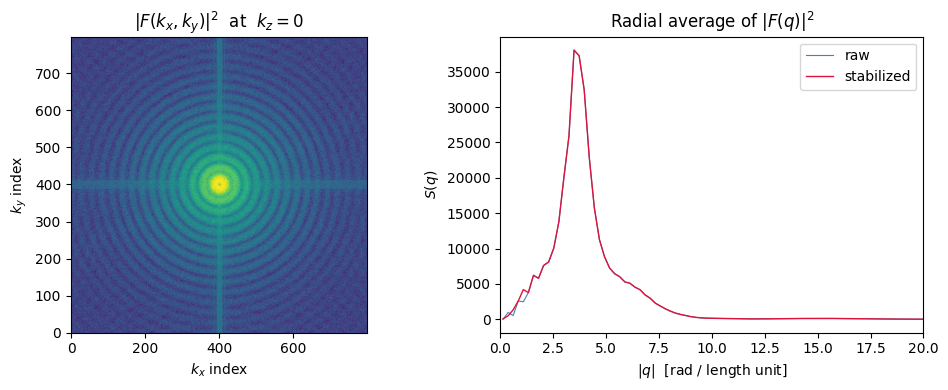

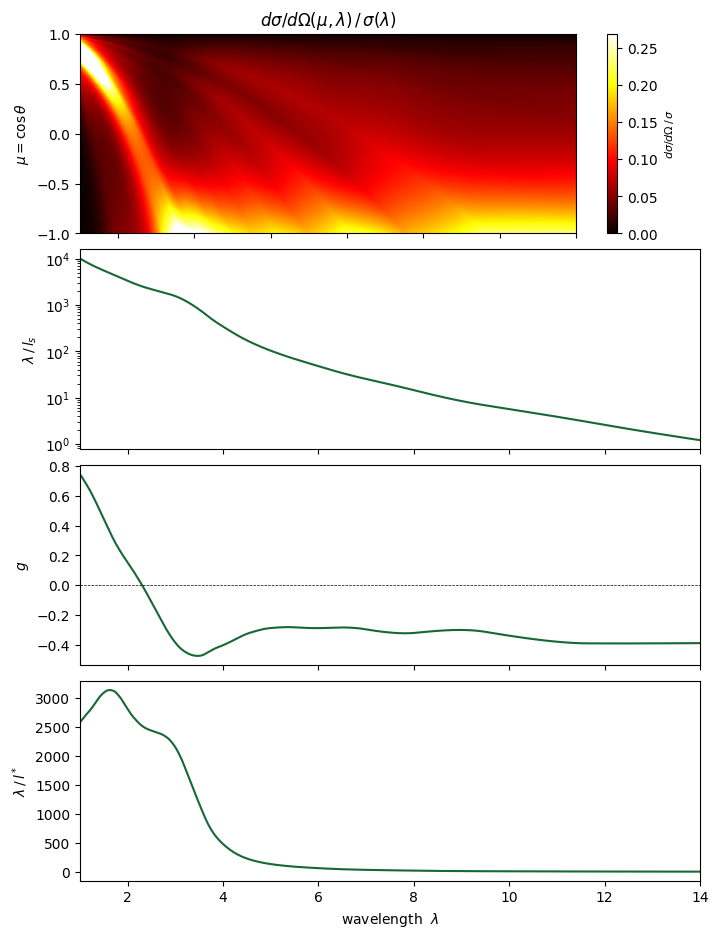

In [10]:
# Assuming your eps array and physical setup:
results = rdg_spectrum(
    permittivity_grid,
    box_size=BOX_SIZE,           # or (Lx, Ly, Lz)
    n_bg=1.0,
    wavelengths=np.linspace(1, 14, 500),  # fine sampling for smooth curves
    n_lowq_skip=5,
    n_lowq_fit=15,
)

fig1 = plot_structure_factor(results)   # replicates Image 1
fig2 = plot_rdg_results(results, characteristic_length=1)  # replicates Image 2

In [11]:
# data_store=[results["wavelengths"],results["g"]]

In [12]:
# np.savetxt("./data/20250312_g_values_ff_0p2172_n_2p9275", np.transpose(data_store) , fmt="%.18f", delimiter=" ", header="lambda g", comments="")


In [13]:
# data_store = [results["q_centers"], results["S_q_raw"]]
# np.savetxt("./data/20250312_S_q_ff_0p2172_n_2p9275.txt", np.transpose(data_store) , fmt="%.18f", delimiter=" ", header="q_centers S_q_raw", comments="")